In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
%matplotlib inline

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

<Axes: xlabel='survived'>

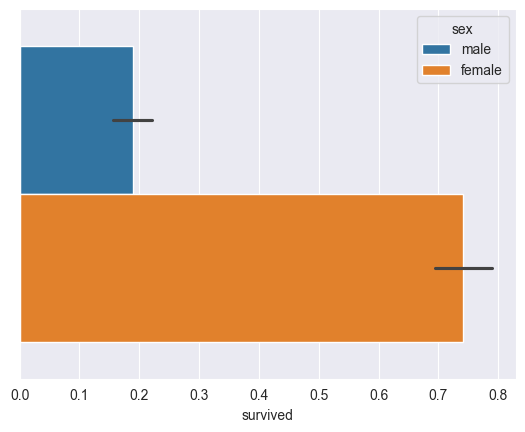

In [9]:
sns.barplot(data=df, x="sex", hue="survived")

<Axes: xlabel='survived', ylabel='count'>

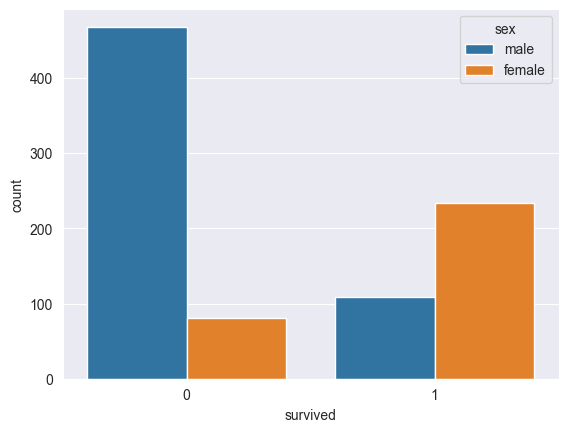

In [7]:
sns.countplot(data=df, x="survived", hue="sex")

<Axes: xlabel='pclass', ylabel='count'>

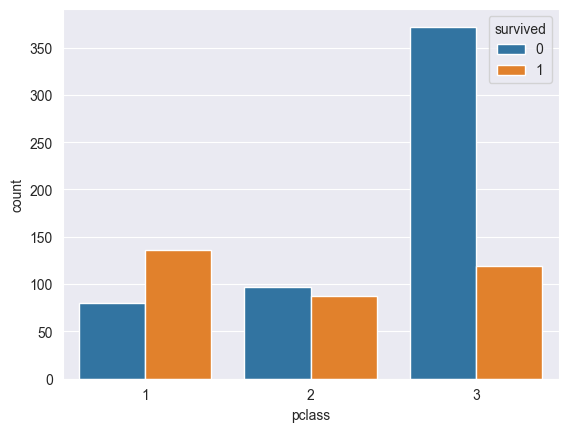

In [12]:
sns.countplot(data=df, x="pclass", hue="survived")

<Axes: xlabel='age', ylabel='Count'>

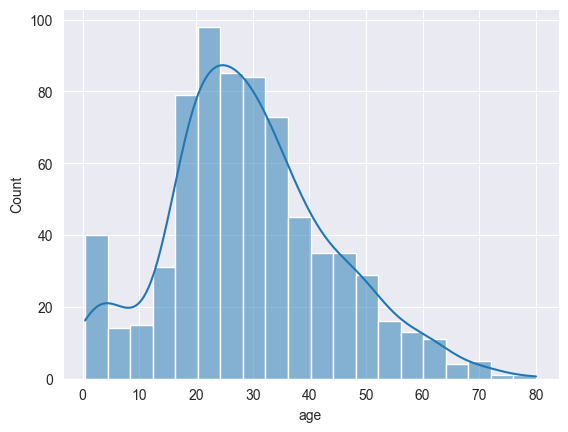

In [15]:
sns.histplot(data=df, x="age",kde=True)

<Axes: xlabel='age', ylabel='Count'>

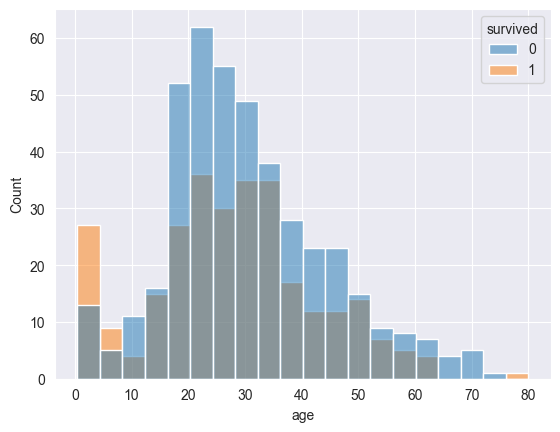

In [14]:
sns.histplot(data=df, x="age", hue="survived")

<Axes: xlabel='who', ylabel='count'>

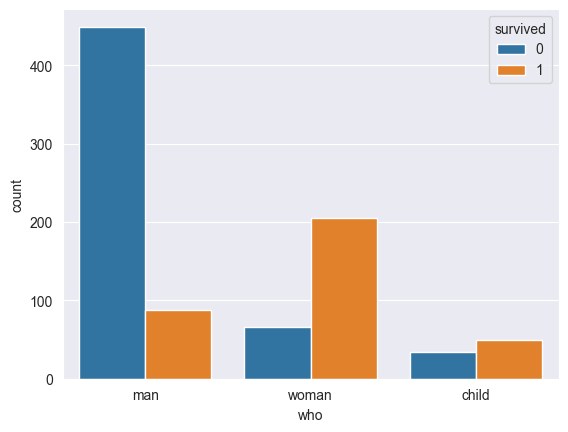

In [17]:
sns.countplot(data=df, x="who", hue="survived")

In [18]:
#feature engineering

In [19]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [20]:
df.shape

(891, 15)

In [22]:
df = df.drop(["deck","embark_town","alive"],axis=1)

In [23]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,True


In [25]:
df.isna().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
alone           0
dtype: int64

In [26]:
df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [27]:
df.isna().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    object  
 8   class       891 non-null    category
 9   who         891 non-null    object  
 10  adult_male  891 non-null    bool    
 11  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(3)
memory usage: 65.5+ KB


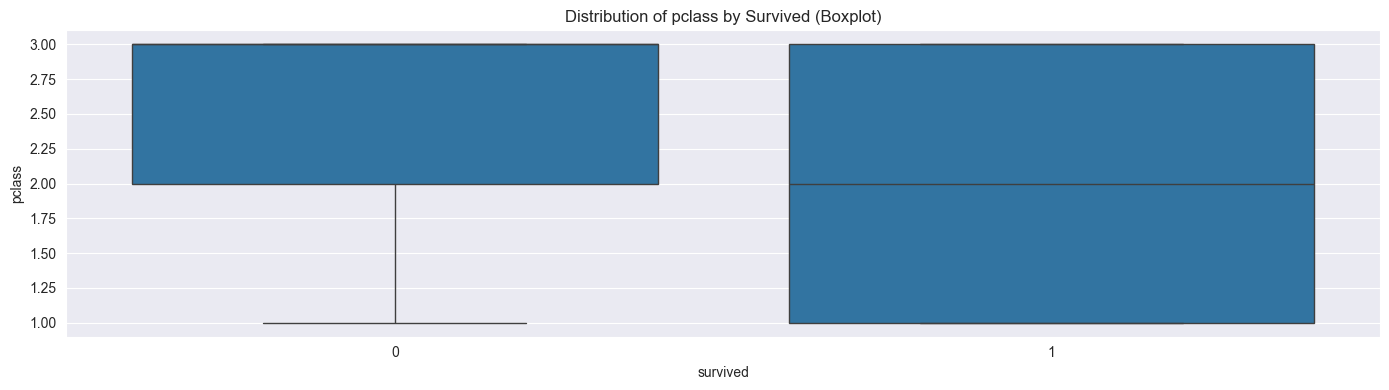

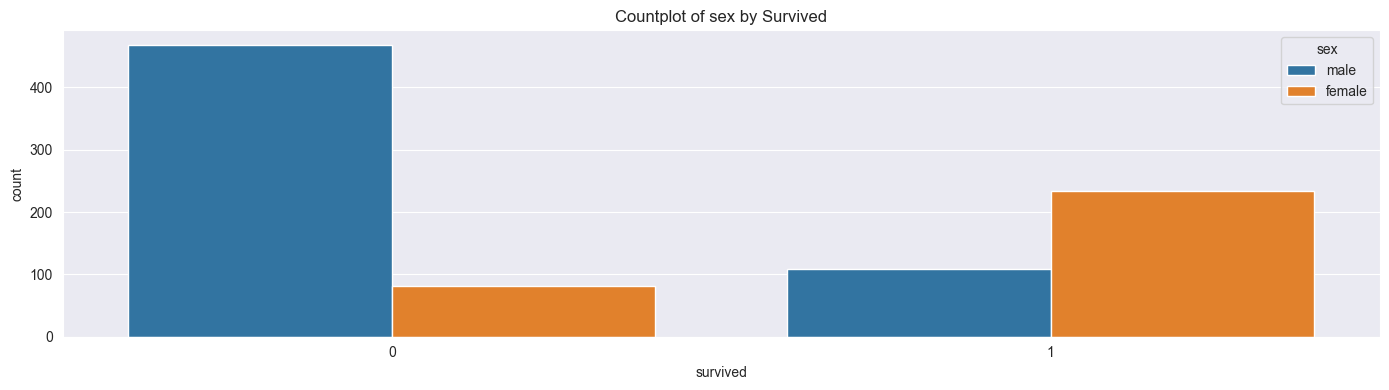

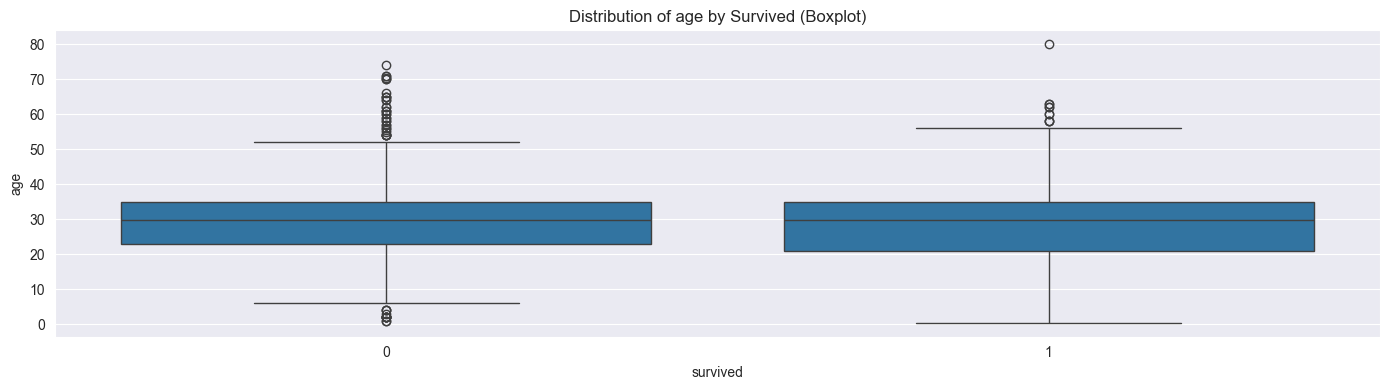

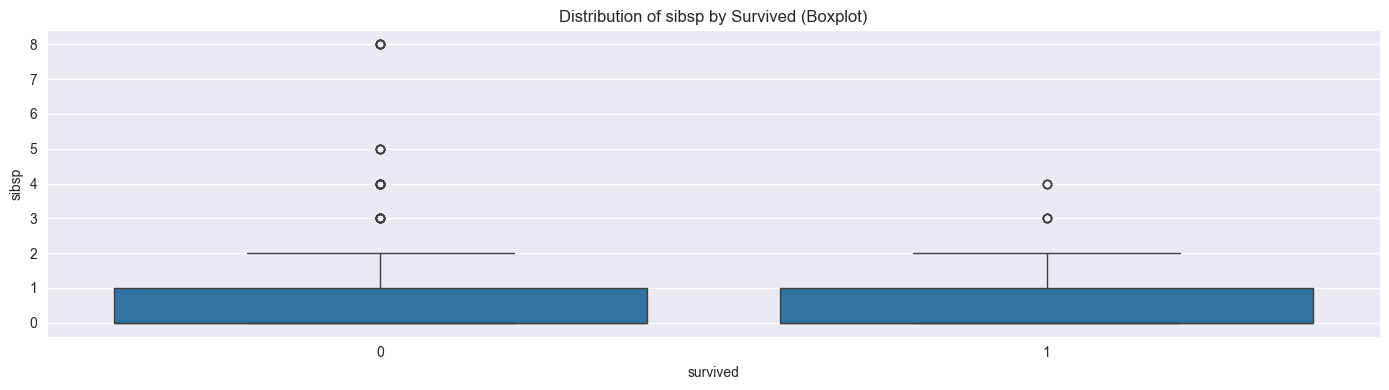

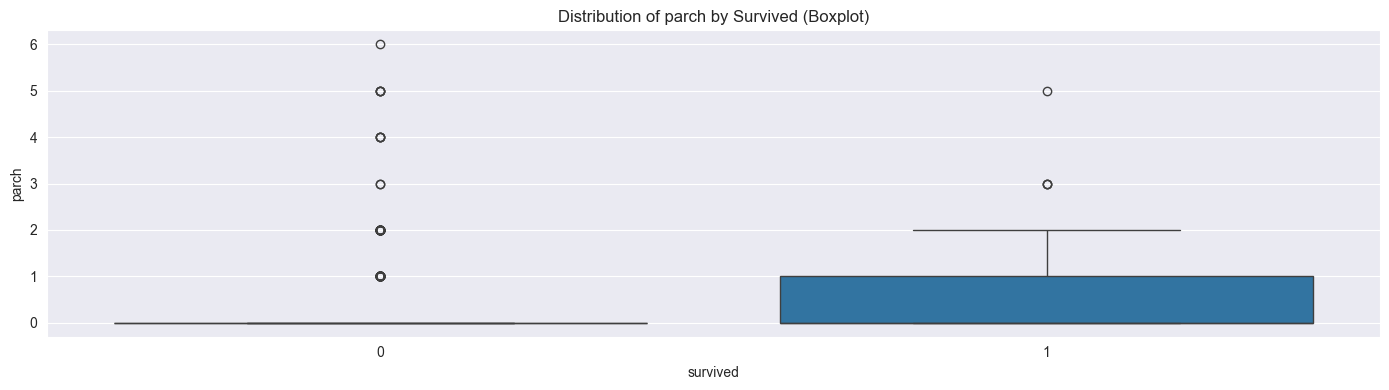

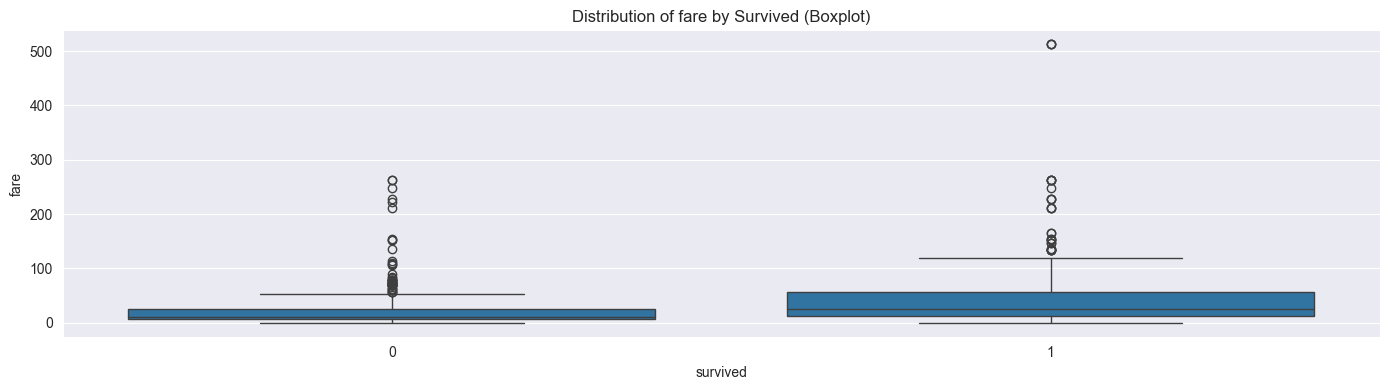

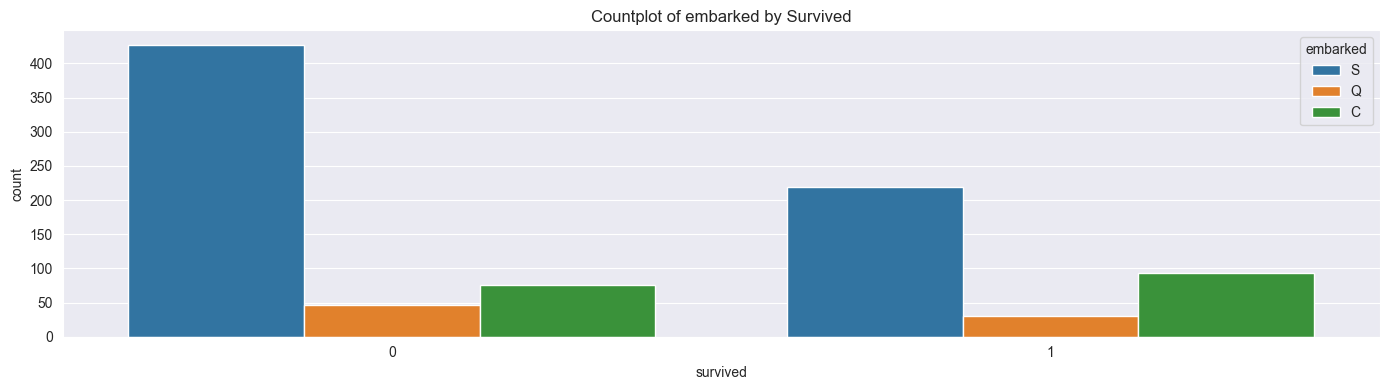

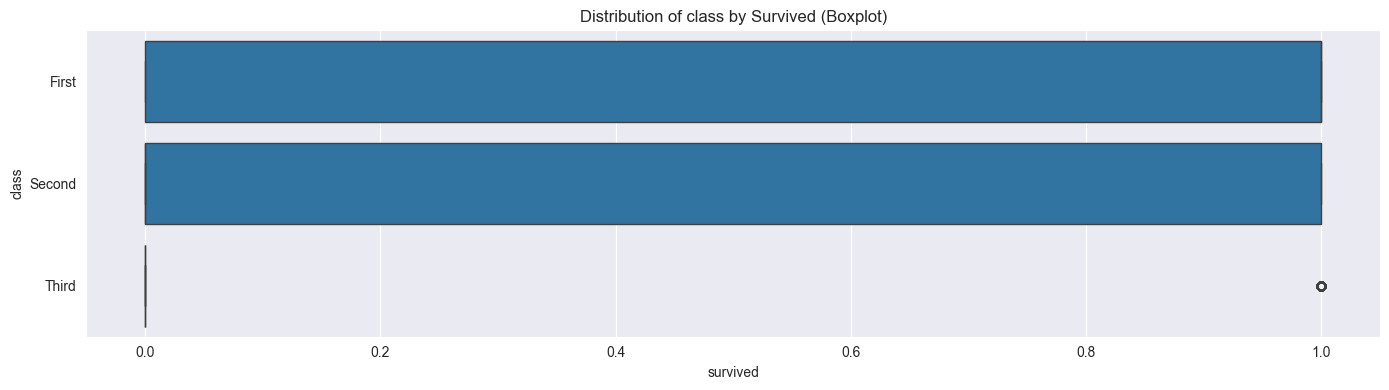

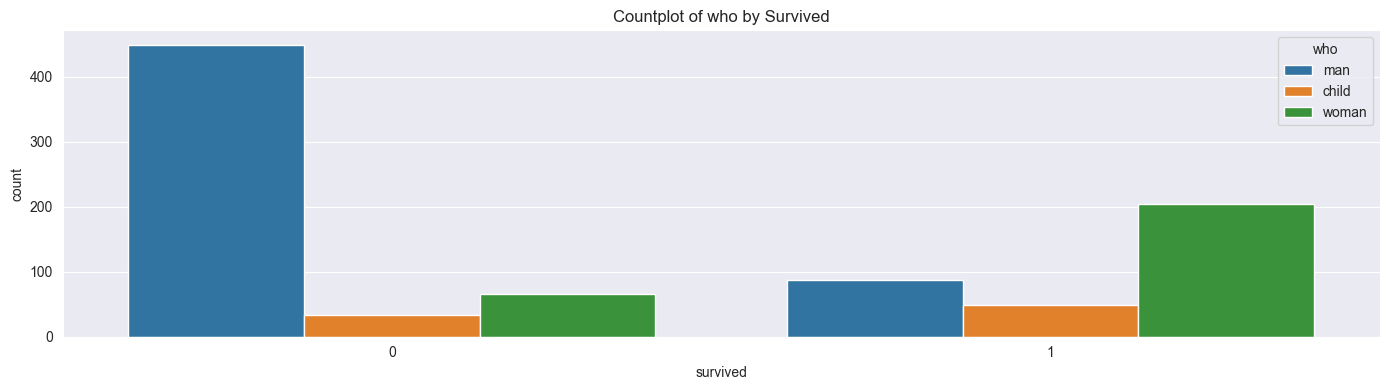

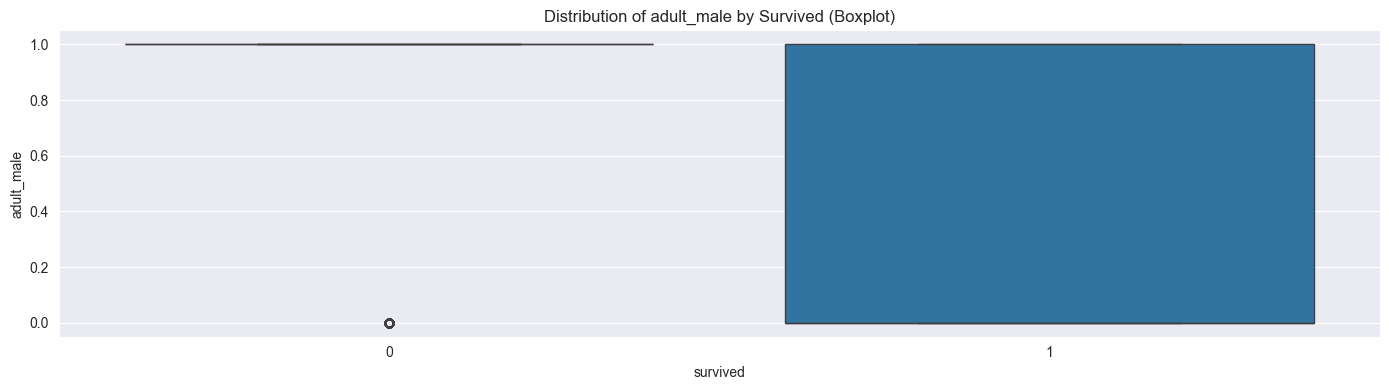

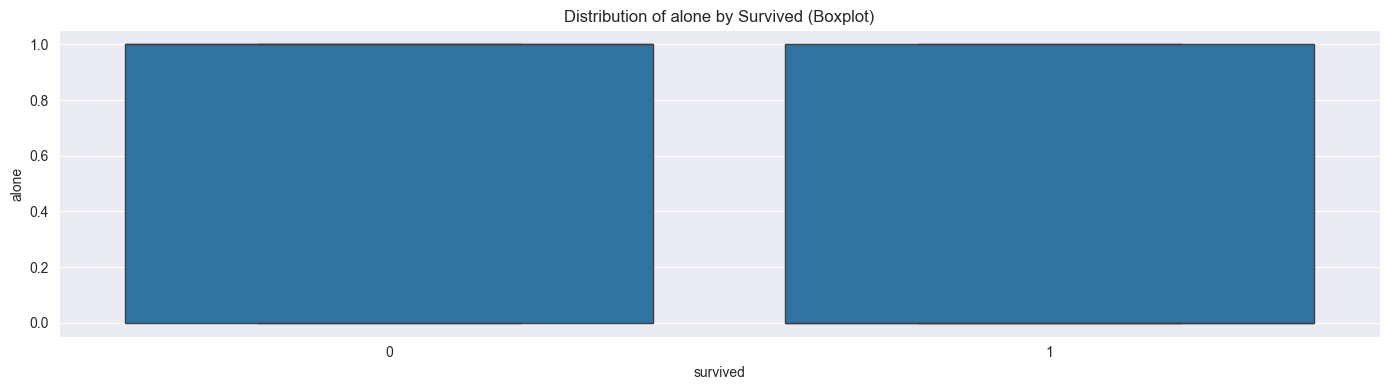

In [40]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != "O"]
categorical_features = [feature for feature in df.columns if df[feature].dtype == "O"]

for col in df.columns:
    if col == "survived":
        continue  # target değişkeni atla

    plt.figure(figsize=(14, 4))

    if col in numeric_features:   # sayısal kabul
        sns.boxplot(data=df, x="survived", y=col)
        plt.title(f"Distribution of {col} by Survived (Boxplot)")
    if col in categorical_features:              # kategorik kabul
        sns.countplot(data=df, x="survived", hue=col)
        plt.title(f"Countplot of {col} by Survived")

    plt.tight_layout()
    plt.show()


In [41]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'alone'],
      dtype='object')

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    object  
 8   class       891 non-null    category
 9   who         891 non-null    object  
 10  adult_male  891 non-null    bool    
 11  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(3)
memory usage: 65.5+ KB


In [43]:
df["alone"] = df["alone"].astype(int)
df["adult_male"] = df["adult_male"].astype(int)

In [44]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [47]:
categorical_cols = ["sex","class","embarked","who"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder = "passthrough"
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [48]:
encoded_cols = preprocessor.get_feature_names_out()

In [50]:
X_train = pd.DataFrame(X_train, columns=encoded_cols)
X_test = pd.DataFrame(X_test, columns=encoded_cols)

In [51]:
X_train

,cat__sex_female,cat__sex_male,cat__class_First,cat__class_Second,cat__class_Third,cat__embarked_C,cat__embarked_Q,cat__embarked_S,cat__who_child,cat__who_man,cat__who_woman,remainder__pclass,remainder__age,remainder__sibsp,remainder__parch,remainder__fare,remainder__adult_male,remainder__alone
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,2.000000,1.0,1.0,26.0000,0.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,54.000000,0.0,1.0,77.2875,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,21.000000,0.0,0.0,10.5000,0.0,1.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,18.000000,1.0,1.0,20.2125,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,20.000000,1.0,0.0,7.9250,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,29.699118,0.0,0.0,7.8958,1.0,1.0
708,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,19.000000,0.0,0.0,30.0000,0.0,1.0
709,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,48.000000,1.0,0.0,76.7292,1.0,0.0
710,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,18.000000,0.0,0.0,11.5000,1.0,1.0


In [71]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [72]:
lgb_model = lgb.LGBMClassifier(verbose=1, n_jobs=-1)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 266, number of negative: 446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373596 -> initscore=-0.516823
[LightGBM] [Info] Start training from score -0.516823
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [73]:
y_pred = lgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[82 21]
 [17 59]]
0.7877094972067039
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       103
           1       0.74      0.78      0.76        76

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.79      0.79      0.79       179



In [74]:
#hangi kolon ne kadar etki ediyor görmek için kullanabiliriz
importances = lgb_model.feature_importances_

feature_names = X_train.columns
feature_importance = pd.DataFrame(
    {"Feature": feature_names,
     "Importances": importances
     }
).sort_values(by="Importances", ascending=False)

In [75]:
feature_importance

,Feature,Importances
15,remainder__fare,1168
12,remainder__age,955
13,remainder__sibsp,82
14,remainder__parch,78
0,cat__sex_female,54
7,cat__embarked_S,51
4,cat__class_Third,49
17,remainder__alone,39
5,cat__embarked_C,37
3,cat__class_Second,30


In [76]:
#hyperparameter tuning

In [77]:
from sklearn.model_selection import RandomizedSearchCV

In [78]:
lgb_model2 = lgb.LGBMClassifier(verbosity=-1)

In [79]:
params = {
    "n_estimators":[100,200,300,500],
    "learning_rate": [0.1,0.05,0.01,1],
    "max_depth":[2,3,4,5],
    "num_leaves":[2,3,4,5,16,32],
    "min_child_samples":[10,20,30],
    "subsample":[0.5,0.8,0.9],
    "colsample_bytree":[0.5,0.8,0.9],
}

In [89]:
random_search = RandomizedSearchCV(lgb.LGBMClassifier(),param_distributions=params,n_jobs=-1,cv=5,verbose=1,scoring="accuracy")
random_search.fit(X_train,y_train)
y_pred2 = random_search.predict(X_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 266, number of negative: 446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373596 -> initscore=-0.516823
[LightGBM] [Info] Start training from score -0.516823


In [90]:
random_search.best_params_

{'subsample': 0.8,
 'num_leaves': 5,
 'n_estimators': 300,
 'min_child_samples': 10,
 'max_depth': 4,
 'learning_rate': 0.1,
 'colsample_bytree': 0.5}

In [91]:
print(classification_report(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(accuracy_score(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86       103
           1       0.81      0.82      0.81        76

    accuracy                           0.84       179
   macro avg       0.83      0.84      0.83       179
weighted avg       0.84      0.84      0.84       179

[[88 15]
 [14 62]]
0.8379888268156425


In [83]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100)
xgb.fit(X_train,y_train)
y_pred3 = xgb.predict(X_test)
print(classification_report(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(accuracy_score(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82       103
           1       0.76      0.75      0.75        76

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179

[[85 18]
 [19 57]]
0.7932960893854749


In [86]:
param = {
    "n_estimators":[100,200,300,500],
    "learning_rate": [0.1,0.05,0.01,1],
    "max_depth":[2,3,4,5],
    "colsample_bytree":[0.5,0.8,0.9],
}

In [87]:
random_search2 = RandomizedSearchCV(estimator=XGBClassifier(),param_distributions=param,n_jobs=-1,scoring="accuracy",cv=5)
random_search2.fit(X_train,y_train)
y_pred4 = random_search2.predict(X_test)
print(classification_report(y_test, y_pred4))
print(confusion_matrix(y_test, y_pred4))
print(accuracy_score(y_test, y_pred4))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       103
           1       0.83      0.78      0.80        76

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

[[91 12]
 [17 59]]
0.8379888268156425
